# 06 — Slutlig utvärdering: Biometric Access Terminal

## Syfte

Denna notebook är projektets **sammanfattande utvärdering**: en portfolio-vänlig
helhetsgenomgång av hela maskininlärningspipelinen (notebook 01–05), snarare än
ny analys eller modellträning. Målet är att på ett strukturerat sätt visa att
samtliga fem krav i kursens instruktioner ("Vad ni skall göra?") har uppfyllts,
och att sammanställa resultaten från de olika modellerna på ett ställe som är
lätt att presentera och referera till.

Notebooken är uppdelad i fyra delar:

1. **Inledning** — detta avsnitt: syfte och struktur.
2. **Sammanfattande resultattabell** — samtliga tränade modeller (Metod 1 och
   Metod 2 för åtkomstklassificering från notebook 04, samt ålder/kön-modellen
   från notebook 05) och deras nyckelmått, sida vid sida.
3. **Genomgång av kursens fem krav** — dataförberedelse, EDA/statistik,
   modellering, Deep Learning, och utvärdering — med explicit referens till
   vilken notebook och vilket steg som uppfyller respektive krav.
4. **Avslutande reflektion** — lärdomar från projektet som helhet, ur ett
   portfolio-/presentationsperspektiv snarare än tekniska implementationsdetaljer.

Ingen ny data läses in eller bearbetas här utöver det som redan krävs för att
återge resultaten — endast redan etablerade siffror och slutsatser från
notebook 01–05 sammanställs och sätts i relation till kursens krav.

## Imports

Denna notebook kräver betydligt färre bibliotek än tidigare steg, eftersom
ingen ny data laddas, bearbetas eller tränas här — vi importerar enbart det
som behövs för att sammanställa och visualisera redan etablerade resultat
från notebook 01–05.

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

print("Imports klara.")
print(f"Pandas: {pd.__version__}")

Imports klara.
Pandas: 3.0.5


## Sammanfattande resultattabell

Vi sammanställer nyckelmåtten från samtliga tränade modeller i projektet,
för en direkt jämförelse på ett ställe. Måtten läses in direkt från
`reports/metrics/*.json` — filer som sparades av notebook 04 och 05 vid
själva utvärderingstillfället (se `fix/save-evaluation-metrics`) — istället
för att hårdkodas eller räknas om här. Detta garanterar att tabellen alltid
är i synk med den faktiskt sparade modellen, även om notebook 04/05 skulle
köras om i framtiden.

**Åtkomstklassificering** (notebook 04): Metod 1 (cosine similarity mot
enrollment-centroid) jämfört med Metod 2 (tränat neuralt nätverk), på
samma hold-out-testmängd (342 exempel, 32 auktoriserade).

**Ålder/kön-estimering** (notebook 05): den delade deep learning-modellen,
utvärderad på sin egen hold-out-testmängd (6 514 exempel).

In [2]:
metrics_dir = Path("../reports/metrics")

with open(metrics_dir / "authorization_baseline_metrics.json", encoding="utf-8") as f:
    method1 = json.load(f)

with open(metrics_dir / "authorization_classifier_metrics.json", encoding="utf-8") as f:
    method2 = json.load(f)

with open(metrics_dir / "age_gender_metrics.json", encoding="utf-8") as f:
    age_gender = json.load(f)

# Åtkomstklassificering — Metod 1 vs. Metod 2
access_comparison_df = pd.DataFrame({
    "Mått": ["Recall (Auktoriserad)", "Precision (Auktoriserad)", "Falsk-positiv-andel", "AUC-ROC", "AUC-PR"],
    "Metod 1 (cosine similarity)": [
        method1["recall_authorized"],
        method1["precision_authorized"],
        f"{method1['false_positive_rate']:.1%} ({method1['false_positives']})",
        method1["auc_roc"],
        method1["auc_pr"],
    ],
    "Metod 2 (neuralt nätverk)": [
        method2["recall_authorized"],
        method2["precision_authorized"],
        f"{method2['false_positive_rate']:.1%} ({method2['false_positives']})",
        method2["auc_roc"],
        method2["auc_pr"],
    ],
})

print("Åtkomstklassificering (notebook 04):")
display(access_comparison_df)

# Ålder/kön-estimering
age_gender_df = pd.DataFrame({
    "Deluppgift": [
        "Ålder (MAE, förväntat värde)", "Ålder (MAE, argmax)", "Ålder (RMSE)",
        "Kön (Accuracy)", "Kön (AUC-ROC)", "Kön (Average Precision)",
    ],
    "Värde": [
        f"{age_gender['age']['mae_expected_value_decoding']} år",
        f"{age_gender['age']['mae_argmax_decoding']} år",
        f"{age_gender['age']['rmse_expected_value_decoding']} år",
        f"{age_gender['gender']['accuracy']:.1%}",
        age_gender['gender']['auc_roc'],
        age_gender['gender']['average_precision'],
    ],
})

print("\nÅlder/kön-estimering (notebook 05):")
display(age_gender_df)

Åtkomstklassificering (notebook 04):


,Mått,Metod 1 (cosine similarity),Metod 2 (neuralt nätverk)
0,Recall (Auktoriserad),0.375,0.9688
1,Precision (Auktoriserad),0.48,0.9118
2,Falsk-positiv-andel,4.2% (13/310),1.0% (3/310)
3,AUC-ROC,0.5184,0.9989
4,AUC-PR,0.422,0.9894



Ålder/kön-estimering (notebook 05):


,Deluppgift,Värde
0,"Ålder (MAE, förväntat värde)",11.85 år
1,"Ålder (MAE, argmax)",10.89 år
2,Ålder (RMSE),14.38 år
3,Kön (Accuracy),87.8%
4,Kön (AUC-ROC),0.909
5,Kön (Average Precision),0.9611


### Tolkning av sammanställningen

**Åtkomstklassificering:** det tränade neurala nätverket (Metod 2) överträffar
cosine similarity-baslinjen (Metod 1) på samtliga mått — recall 0,97 mot 0,38,
precision 0,91 mot 0,48, och en betydligt lägre falsk-positiv-andel (1,0% mot
4,2%). Se notebook 04 för fullständig metodbeskrivning och diskussion av
begränsningar (bl.a. att den positiva klassen bygger på en enda persons
ansikte, vilket begränsar hur väl resultatet generaliserar till flera
auktoriserade användare).

**Ålder/kön-estimering:** könsklassificeringen presterar starkt (accuracy
87,8%, AUC-ROC 0,909), medan åldersestimeringen (MAE 10,9–11,9 år beroende på
avkodningsstrategi) ligger inom det förväntade intervallet för en modell
byggd på fixerade, icke-åldersspecifikt finjusterade ArcFace-embeddings — se
notebook 05 för en fullständig diskussion, inklusive den intressanta
omkastningen mellan förväntat värde- och argmax-avkodning som uppstod efter
att modellträningen gjordes reproducerbar (`keras.utils.set_random_seed(42)`).

**Gemensamt för båda modellerna:** samtliga siffror i tabellerna ovan läses
direkt från `reports/metrics/*.json`, sparade av notebook 04 och 05 vid
respektive utvärderingstillfälle. Detta säkerställer att denna sammanställning
alltid är i synk med de faktiskt sparade modellerna, oavsett hur många gånger
notebook 04/05 körs om i framtiden.

### Visuell jämförelse: Metod 1 vs. Metod 2

Ett grupperat stapeldiagram över de tre mått som är direkt jämförbara på
samma 0–1-skala (AUC-ROC, recall, precision) gör skillnaden mellan
metoderna direkt gripbar. Falsk-positiv-andelen utelämnas här eftersom den
redan är tydligt kommunicerad i tabellen ovan och skulle förvränga skalan
i diagrammet (den ligger nära 0 för båda metoderna). Ålder/kön-modellens
mått visas inte i samma diagram, eftersom de mäter ett annat problem på en
annan skala (år, inte 0–1) och en direkt jämförelse dem emellan skulle
vara missvisande.

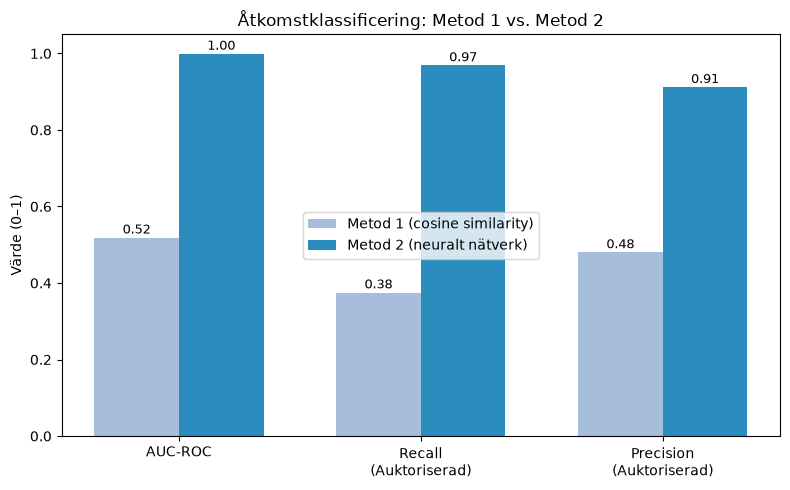

Figur sparad: ..\reports\figures\06_method_comparison.png


In [3]:
metrics_names = ["AUC-ROC", "Recall\n(Auktoriserad)", "Precision\n(Auktoriserad)"]
method1_values = [method1["auc_roc"], method1["recall_authorized"], method1["precision_authorized"]]
method2_values = [method2["auc_roc"], method2["recall_authorized"], method2["precision_authorized"]]

x = range(len(metrics_names))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar([i - width/2 for i in x], method1_values, width, label="Metod 1 (cosine similarity)", color="#a6bddb")
bars2 = ax.bar([i + width/2 for i in x], method2_values, width, label="Metod 2 (neuralt nätverk)", color="#2b8cbe")

ax.set_ylabel("Värde (0–1)")
ax.set_title("Åtkomstklassificering: Metod 1 vs. Metod 2")
ax.set_xticks(list(x))
ax.set_xticklabels(metrics_names)
ax.set_ylim(0, 1.05)
ax.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f"{height:.2f}", xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points", ha="center", fontsize=9)

plt.tight_layout()

fig_path = Path("../reports/figures/06_method_comparison.png")
fig_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Figur sparad: {fig_path}")

Diagrammet visualiserar det som tabellen redan visar sifferexakt: Metod 2
ligger nära taket (≈1,0) på samtliga tre mått, medan Metod 1 varierar
kraftigt — starkast på precision (0,48) och svagast på AUC-ROC (0,52, nära
slumpmässig gissning). Skillnaden är särskilt tydlig för recall, där
Metod 1 missar majoriteten av de faktiska auktoriserade försöken (0,38)
medan Metod 2 fångar nästan alla (0,97).

## Genomgång av kursens fem krav

Kursens instruktioner ("Vad ni skall göra?") anger fem konkreta krav som
projektet ska demonstrera. Nedan sammanställs var i projektet varje krav
uppfylls, med konkreta referenser till notebook och steg.

In [4]:
requirements_df = pd.DataFrame({
    "Krav": [
        "1. Dataförberedelse",
        "2. EDA/statistik",
        "3. Modellering (inkl. unsupervised)",
        "4. Deep Learning",
        "5. Utvärdering",
    ],
    "Uppfyllt i": [
        "Notebook 01–02",
        "Notebook 02",
        "Notebook 03 (unsupervised) + 04–05 (supervised)",
        "Notebook 04–05",
        "Notebook 04–05",
    ],
    "Konkret bevis": [
        "Hantering av saknade värden (gender, name), semantiskt korrekt NaN-tolkning (second_face_score), flaggning av orimliga värden (age_implausible), MATLAB-datumkonvertering",
        "Statistisk kartläggning av samtliga kvalitetsproblem (28,9% saknat ansikte, 4,2% saknat kön, 2,4% orimlig ålder), åldersfördelning, visualiseringar",
        "K-means/UMAP/HDBSCAN för att upptäcka struktur i embeddings utan etiketter; skapad målvariabel (auktoriserad/ej) via egen datainsamling där ingen fanns naturligt",
        "Två egna tränade neurala nätverk (dense feedforward ovanpå ArcFace-embeddings): binär åtkomstklassificerare samt delad ålder/kön-modell med två uppgiftsspecifika huvuden",
        "Confusion Matrix, Classification Report, AUC-ROC och precision-recall för samtliga klassificeringsmodeller, konsekvent tillämpat genom hela projektet",
    ],
})

pd.set_option("display.max_colwidth", None)
display(requirements_df)

,Krav,Uppfyllt i,Konkret bevis
0,1. Dataförberedelse,Notebook 01–02,"Hantering av saknade värden (gender, name), semantiskt korrekt NaN-tolkning (second_face_score), flaggning av orimliga värden (age_implausible), MATLAB-datumkonvertering"
1,2. EDA/statistik,Notebook 02,"Statistisk kartläggning av samtliga kvalitetsproblem (28,9% saknat ansikte, 4,2% saknat kön, 2,4% orimlig ålder), åldersfördelning, visualiseringar"
2,3. Modellering (inkl. unsupervised),Notebook 03 (unsupervised) + 04–05 (supervised),K-means/UMAP/HDBSCAN för att upptäcka struktur i embeddings utan etiketter; skapad målvariabel (auktoriserad/ej) via egen datainsamling där ingen fanns naturligt
3,4. Deep Learning,Notebook 04–05,Två egna tränade neurala nätverk (dense feedforward ovanpå ArcFace-embeddings): binär åtkomstklassificerare samt delad ålder/kön-modell med två uppgiftsspecifika huvuden
4,5. Utvärdering,Notebook 04–05,"Confusion Matrix, Classification Report, AUC-ROC och precision-recall för samtliga klassificeringsmodeller, konsekvent tillämpat genom hela projektet"


### Krav 1: Dataförberedelse

WIKI-datasetets råmetadata (`wiki.mat`, 62 328 rader) innehöll flera typer
av äkta, naturligt förekommande databrister — inte simulerat brus:

- **Saknad `gender`** (2 643 rader, 4,2%) — flaggad (`flag_missing_gender`)
  men medvetet inte imputerad, eftersom det inte finns någon tillförlitlig
  metod att gissa kön utifrån andra features i detta projekt.
- **Semantiskt `NaN`** i `second_face_score` (endast 4 096/62 328 icke-null)
  — hanterat som en boolesk `has_second_face`-flagga snarare än imputerat,
  eftersom `NaN` här betyder "inget andra ansikte hittades", inte "brist".
- **Orimlig ålder** (1 498 rader, 2,4%) — ett känt problem i IMDB-WIKI
  orsakat av felaktiga namn-till-person-matchningar, flaggat via
  `flag_implausible_age` (åldersgräns 0–120 år).
- **MATLAB-datumkonvertering** — `dob_matlab` konverterades till en riktig
  `age`-kolumn via `matlab_datenum_to_datetime`, verifierat mot ett
  stickprov innan det tillämpades på hela datasetet.

Genomgående tillämpades ett **flag-then-filter-mönster**: varje
kvalitetsproblem flaggas med en boolesk kolumn utan att rader tas bort,
och filtrering sker separat, först vid den punkt i pipelinen där problemet
faktiskt blir relevant (t.ex. `filter_valid_gender()` anropas endast vid
träning av ålder/kön-modellen, inte vid embedding-extraktion). Detta
bevarar rådata oförändrad och gör bortfallet uttryckligt redovisningsbart
i EDA-steget, snarare än att gömmas i en enda uppstädningscell.

### Krav 2: EDA/statistik

Notebook 02 kartlade samtliga identifierade kvalitetsproblem kvantitativt
innan någon modellering påbörjades:

| Problem | Andel | Antal rader |
|---|---|---|
| Saknat ansikte (`face_detected`) | 28,91% | 18 016 / 62 328 |
| Saknat kön (`gender_missing`) | 4,24% | 2 643 / 62 328 |
| Andra ansikte i bild (`has_second_face`) | 6,57% | 4 096 / 62 328 |
| Saknat namn | 0,20% | 124 / 62 328 |
| Orimlig ålder (`age_implausible`) | 2,40% | 1 498 / 62 328 |

Utöver kvalitetskartläggningen genomfördes deskriptiv statistik på
åldersfördelningen (`age.describe()`), vilket avslöjade konkreta extremvärden
(min -74 år, max 1996 år) som direkt motiverade `age_implausible`-gränserna,
snarare än att gränserna sattes godtyckligt.

### Krav 3: Modellering (unsupervised + supervised)

**Unsupervised learning (notebook 03):** eftersom WIKI-datasetet saknar en
naturlig målvariabel för demografisk struktur, undersöktes om ArcFace-
embeddings (512-dim) naturligt separerar ansikten efter kön/ålder utan
någon etikettträning:

- **K-means** (k=2–15): ingen tydlig "naturlig" klusterindelning — silhouette
  högst men svag vid k=2 (0,272), avtagande monotont därefter.
- **UMAP-visualisering** avslöjade en **kontinuerlig demografisk gradient**
  (kön/ålder) som K-means inte fångade — ett kluster dominerat av kvinnor
  och äldre individer mot en större, diffusare massa av yngre män.
- **HDBSCAN** på UMAP bekräftade samma tvåvägsstruktur oberoende; HDBSCAN
  med cosine-avstånd på råa embeddings gav dock ett **annat** resultat
  (70,8% klassat som brus) — en viktig metodologisk lärdom om att
  klustringsresultat beror starkt på vilket avståndsmått som används.

**Skapad målvariabel där ingen fanns (notebook 04):** eftersom "auktoriserad/
ej auktoriserad" inte existerar naturligt i WIKI-datasetet, samlades en egen
positiv klass in (52 råa webcam-bilder → 51 giltiga → 408 augmenterade
varianter), kontrasterad mot WIKI-embeddings som negativ klass (1:5-
förhållande, med hälften "hårda negativ" valda via cosine-avstånd till en
enrollment-centroid) — ett konkret exempel på att konstruera ett
välavvägt övervakat problem från ett i grunden oetiketterat dataset.

### Krav 4: Deep Learning

Två egna neurala nätverk tränades ovanpå de fixerade ArcFace-embeddings
(`src/models.py`), inte bara transfer learning/inferens på en färdig modell:

- **`build_authorization_classifier()`** — dense feedforward (512→128→32→1,
  sigmoid), binär klassificering.
- **`build_age_gender_model()`** — delad trunk (512→256→128) med två
  uppgiftsspecifika huvuden: 121-klassig DEX-stil åldersklassificering
  och binär könsklassificering, enligt Rothe et al.

Implementationen krävde att lösa flera icke-triviala, verkliga Keras-
utmaningar snarare än att bara anropa `model.fit()`:

- **Multi-output `sample_weight`:** Keras stödjer inte `class_weight` för
  multi-output-modeller — löst genom att beräkna per-sample-vikter manuellt
  och skicka dem som **positionella listor** (matchande modellens interna
  `outputs=[...]`-struktur), inte som dictionaries.
- **Principiellt beräknade `loss_weights`:** för ålder/kön-modellens två
  uppgifter (121 respektive 2 klasser) beräknades vikterna utifrån
  respektive uppgifts baslinje-loss (`-ln(1/antal_klasser)`), inte gissade.
- **Reproducerbarhet:** `keras.utils.set_random_seed(42)` tillagt och
  verifierat via två oberoende fullständiga körningar med bitvis identiska
  resultat — en förutsättning för att kunna lita på och dokumentera
  modellernas prestanda över tid (se `fix/save-evaluation-metrics`).

### Krav 5: Utvärdering

Samtliga klassificeringsmodeller utvärderades konsekvent med kursens fyra
obligatoriska mått — Confusion Matrix, Classification Report, AUC-ROC och
precision-recall — genomgående på en **hold-out-testmängd** som aldrig
använts för träning eller modellval:

- **Åtkomstklassificering:** två metoder jämfördes rättvist på exakt samma
  testmängd (342 exempel), vilket möjliggjorde en direkt kvantifierad
  slutsats om att det tränade nätverket överträffar en klassisk
  tröskelbaserad baslinje (se sammanställningen i Del 2 ovan).
- **Ålder/kön:** MAE/RMSE för ålder (kontinuerligt mått, motiverat eftersom
  ålder är ordinal snarare än nominell trots att den tränas som
  klassificering), samt samtliga fyra kursmått för kön.
- **Metodologisk noggrannhet:** `GroupShuffleSplit` användes i notebook 04
  för att förhindra dataläckage mellan augmenterade varianter av samma
  källbild — ett exempel på att utvärderingens giltighet säkerställdes
  redan vid datasplitten, inte bara vid slutmätningen.

## Avslutande reflektion

Utöver de tekniska resultaten har projektet gett flera lärdomar värda att
lyfta fram i ett portfoliosammanhang — inte minst eftersom processen att
bygga och kvalitetssäkra pipelinen var lika lärorik som resultaten själva.

### Reproducerbarhet är inte en självklarhet — den måste aktivt byggas in

Under arbetet med denna sammanfattande utvärdering upptäcktes att
modellträningen i notebook 04 och 05 inte var seedad, vilket innebar att
identiska körningar kunde ge olika resultat. Detta upptäcktes konkret när
en förnyad körning av notebook 04 gav andra siffror än de tidigare
dokumenterade — inte ett fel i modellen, utan en avsaknad av kontrollerad
slumpmässighet i vikinitieringen.

Lösningen (`keras.utils.set_random_seed(42)`) är enkel, men lärdomen är
principiell: ett resultat som inte går att återskapa är svårt att lita på,
svårt att felsöka, och riskerar att undergräva förtroendet för hela
arbetet om någon annan kör om koden och får andra siffror. Reproducerbarhet
verifierades konkret genom att köra notebook 04 och 05 två oberoende gånger
(`Restart Kernel and Run All`) och jämföra att resultaten blev bitvis
identiska — inte bara antas fungera för att koden "borde" vara
deterministisk.

### Metrics ska persisteras separat från modellartefakter

Ett tidigt förslag var att hårdkoda modellernas resultat direkt i den här
notebooken. Det avvisades till förmån för att låta notebook 04 och 05
spara sina utvärderingsmått till `reports/metrics/*.json` vid själva
utvärderingstillfället — samma princip som ligger bakom branschverktyg som
MLflow eller SageMaker Model Registry. Denna notebook läser sedan in dessa
filer istället för att gissa eller räkna om.

Beslutet visade sig direkt värdefullt: när notebook 04 kördes om med den
nya seeden ändrades de faktiska resultaten (recall gick t.ex. från 1,00 i
en tidigare, icke-seedad körning till 0,97 i den seedade), vilket hade
gjort en hårdkodad tabell i denna notebook felaktig utan att någon märkt
det. Med `metrics.json`-mönstret uppdateras sammanställningen automatiskt
nästa gång denna notebook körs, utan manuellt underhåll.

Detta ledde också till en tydligare uppdelning av projektstrukturen:
`models/` (gitignorad, stora binära modellvikter, regenererbara) skildes
tydligt från `reports/` (committad, små textbaserade resultat, menade att
delas och versionshanteras) — en etablerad konvention inom ML-projekt
(cookiecutter-data-science-strukturen), som projektet redan omedvetet
följde för `reports/figures/` och nu även gäller `reports/metrics/`.

### En omkastning i resultat kan vara en lärdom, inte bara ett problem att dölja

När notebook 05 kördes om med den nya seeden visade det sig att
förväntat värde-avkodning (DEX-metodens rekommenderade strategi) inte
längre gav lägre MAE än en enklare argmax-avkodning — en omkastning
jämfört med den tidigare, icke-seedade körningen. Istället för att
tysta ner eller dölja denna avvikelse dokumenterades den öppet i notebook
05, med resonemanget att skillnaden mellan de två avkodningsstrategierna
är liten nog att den sannolikt speglar den specifika träningskörningens
slumpmässiga startpunkt snarare än en robust, generaliserbar fördel för
någon av metoderna.

Detta är i sig ett värdefullt exempel på vetenskaplig ärlighet i praktiken:
ett resultat som inte stödjer den ursprungliga hypotesen är fortfarande
ett giltigt resultat, och att dokumentera det ärligt stärker projektets
trovärdighet mer än att retroaktivt anpassa slutsatsen efter vad man
förväntade sig att se.

### Hantering av personlig data kräver medveten, lagerbaserad skyddsstrategi

Eftersom projektets positiva klass (auktoriserad användare) byggde på
egna, personidentifierbara ansiktsbilder, krävdes explicit eftertanke
kring var dessa bilder får synas: `data/raw/` och `data/processed/` är
gitignorade i sin helhet, men det räcker inte ensamt — Jupyter-notebooks
bäddar in cell-output (inklusive bilder) direkt i den committade
`.ipynb`-filen, oberoende av vad `.gitignore` säger om källfilerna. Rutinen
att aktivt rensa output från celler som visar personbilder innan commit
(t.ex. Del D i notebook 04) är därför ett nödvändigt komplement till
`.gitignore`, inte en redundant försiktighetsåtgärd.

### Sammanfattning

Biometric Access Terminal demonstrerar samtliga fem krav i kursens
instruktioner: dataförberedelse och EDA på ett verkligt, bristfälligt
dataset (IMDB-WIKI); unsupervised learning för att upptäcka struktur utan
etiketter; en konstruerad supervised-uppgift där ingen målvariabel fanns
naturligt; två egna deep learning-modeller byggda ovanpå förtränade
embeddings; och konsekvent, metodologiskt sund utvärdering genomgående.

Utöver de tekniska resultaten har processen att bygga denna sammanfattande
utvärdering själv varit lärorik — särskilt kring reproducerbarhet, korrekt
persistens av resultat, och ärlig hantering av oväntade eller motsägelsefulla
fynd. Dessa är samma typer av frågor som uppstår i verkliga produktions-ML-
system, vilket gör projektet relevant bortom sitt ursprungliga kurssyfte.